[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MeteoSwiss/inca-examples/blob/main/notebooks/plotting_inca.ipynb)

# Plot INCA data

In this jupyter notebook, we will show how to import and plot some forecast fields from 
the INCA-CH [nowcasting system](https://www.meteoswiss.admin.ch/services-and-publications/service/weather-and-climate-products/weather-forecasts.html). All available INCA fields can be found on [Zenodo](https://zenodo.org/record/6470725).  A new generation of nowcasting systems is in development. For this reason **only a subset of the current INCA-CH parameters are available trough our open data provision** ([open data](https://github.com/MeteoSwiss/opendata-forecast-data/blob/main/README.md#1-short-term-forecast-data)). 

## Install dependencies

First, let's set up our working environment. It is recommended to use a virtual
environment.

**Important**: In Google Colab, this notebook needs to be executed one cell
at a time. Trying to excecute all the cells at once may results in cells being 
skipped and some dependencies not being installed.

Now, let's install the  dependendies that will allow us to read and visualize the 
example data. To do so, we will use two main python packages: [xarray](http://xarray.pydata.org)
to work with labelled multi-dimensional arrays, [netCDF4](https://pypi.org/project/netCDF4/) for accessing the netcdf files and [matplotlib](https://matplotlib.org/) for visualization.

In [ ]:
!pip install xarray matplotlib netCDF4

## Download the data

Now that we have the environment ready, let's download some example datasets.

On [Zenodo](https://zenodo.org/record/5575197), we can download the ouput from a
single run of INCA for precipitation (mm/h).
On [Zenodo](https://zenodo.org/record/6470725), we can also download the ouput from a
single run of INCA for all produced parameters.

In [ ]:
!wget https://zenodo.org/records/5575197/files/RR_INCA.nc
!wget https://zenodo.org/records/6470725/files/RP_INCA_202106280700.nc
!wget https://zenodo.org/records/6470725/files/FF_10min_INCA_202204131500.nc
!wget https://zenodo.org/records/6470725/files/TT_INCA_202106280700.nc

## Read the data

Now that we have downloaded the example data, let's import the example netCDF 
with `xarray.open_dataset()` method.

The files are called `RR_INCA.nc`,`RP_INCA_202106280700.nc`,`FF_10min_INCA_202204131500.nc` and `TT_INCA_202106280700.nc`. "RR, RP, FF_10min and TT are the variables names used to identify the nowcasting parameters: quantitative total precipitation (nowcasting product based on the merging between
radar and station observations named CombiPrecip, mm/h, updated every 10min with 10min output granularity), qualitative precipitation (nowcasting product based on radar, mm/h, updated every 5 min with 5min output granularity), mean wind at 10 m (updated every 10min with 10im output granularity) and temperature at 2 m (updated every 10min with 60min output granularity). The maximal forecast range is for all parameters 6h.

We import this 6-hour forecast, which corresponds to a sequence of 37,72 or 7 
frames of the coorespoding field (1 analysis and 36/72/6 forecasts).

In [60]:
import xarray as xr
import netCDF4

#precipitation quantitative (10min)
ds1 = xr.open_dataset("RR_INCA.nc")
# precipitation qualitative (5min)
ds2 = xr.open_dataset("RP_INCA_202106280700.nc")
#mean wind
ds3 = xr.open_dataset("FF_10min_INCA_202204131500.nc")
#temperature
ds4 = xr.open_dataset("TT_INCA_202106280700.nc")
ds1

<xarray.Dataset> Size: 67MB
Dimensions:       (chx: 710, chy: 640, time: 37)
Coordinates:
  * chx           (chx) float64 6kB 2.555e+05 2.565e+05 ... 9.635e+05 9.645e+05
  * chy           (chy) float64 5kB -1.595e+05 -1.585e+05 ... 4.795e+05
  * time          (time) datetime64[ns] 296B 2021-07-08T08:20:00 ... 2021-07-...
Data variables:
    RR            (time, chy, chx) float32 67MB ...
    grid_mapping  float32 4B ...
Attributes:
    conventions:     CF-1.6
    conventionsURL:  http://cfconventions.org/cf-conventions/v1.6.0/cf-conven...
    title:           simple NetCDF output
    institution:     MeteoSwiss (NMC Switzerland)
    source:          model: inca-1,product_category: determinist, version: 3.2
    reference:       MeteoSwiss (2021)
    history:         Produced by inca2netcdf 1.0 on 2021-07-08 08:30 UTC
    comment:         Illustrate simplified NetCDF structure when all fields d...

## Basic plotting

Xarray's includes some plotting functionalities that we can use to visualize our example data.

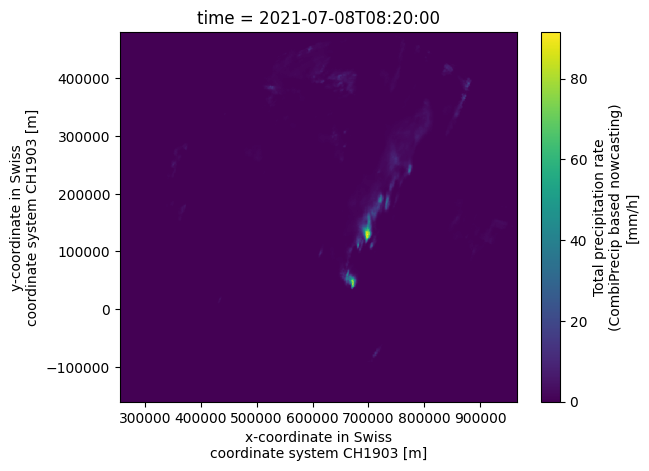

In [45]:
precip_field = ds1.RR.isel(time=0) # select the first rainfall field, that is, the analysis
precip_field.plot()

One can easily add transparency to the dry areas and customize the [colormap](https://matplotlib.org/stable/tutorials/colors/colormaps.html).

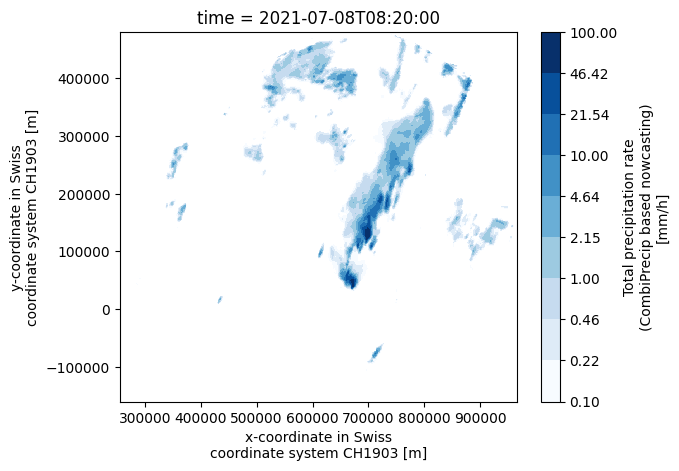

In [46]:
import numpy as np
import matplotlib.pyplot as plt

levels = np.logspace(-1, 2, 10, base=10)
cmap = "Blues"
precip_field.where(precip_field >= 0.1).plot(levels=levels, cmap=cmap)

We can repeat the plotting for qualitative precipitation, mean wind and temperature.

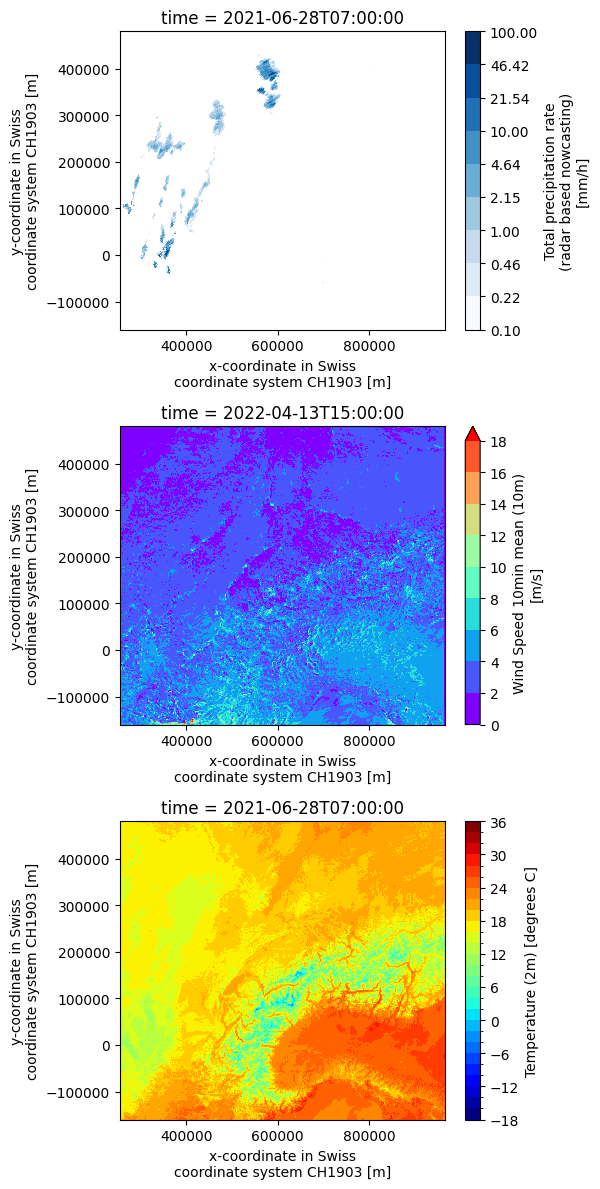

In [61]:
f, ((ax1, ax2, ax3)) = plt.subplots(3, 1,figsize=(6,12))
precip_field = ds2.RP.isel(time=0) # select the first rainfall field, that is, the analysis
levels = np.logspace(-1, 2, 10, base=10)
cmap = "Blues"
precip_field.where(precip_field >= 0.1).plot(levels=levels, cmap=cmap,ax=ax1)

wind_field = ds3.FF_10min.isel(time=0) # select the first wind field, that is, the analysis
levels = np.arange(0,20,2)
cmap = "rainbow"
wind_field.plot(levels=levels, cmap=cmap,ax=ax2)

temp_field = ds4.TT.isel(time=0) # select the first wind field, that is, the analysis
levels = np.arange(-18,38,2)
cmap = "jet"
temp_field.plot(levels=levels, cmap=cmap,ax=ax3)

plt.tight_layout()

## Plot with Cartopy

[Cartopy](https://scitools.org.uk/cartopy) is a python library for plotting georeferenced datasets and maps. 

Installing Cartopy is a bit more involved as it requires few additonal library dependencies. Also, shapely need to be reinstalled by ignoring the binary
wheels to make it compatible with Cartopy.

In [ ]:
!apt-get install -qq libgdal-dev libgeos-dev
!pip uninstall --yes shapely
!pip install shapely --no-binary shapely
!pip install cartopy pyepsg

We first define a method to plot reference geographical features to an existing figure axis.

In [50]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def add_geo_features(ax):
    """
    Add reference geographical layers such as thenational boundaries
    and the main lakes and rivers.
    """
    ax.add_feature(
        cfeature.NaturalEarthFeature(
            "cultural",
            "admin_0_boundary_lines_land",
            scale="10m",
            edgecolor="black",
            facecolor="none",
            linewidth=1,
        )
    )
    ax.add_feature(
        cfeature.NaturalEarthFeature(
            "physical",
            "rivers_lake_centerlines",
            scale="10m",
            edgecolor=np.array([0.59375, 0.71484375, 0.8828125]),
            facecolor="none",
            linewidth=1,
        )
    )

To use Cartopy, we need to specify the source and target coordinate reference system. In our case, the Swiss coordinate system CH1903/LV03 can be identified by the [EPSG 21781](https://epsg.io/21781).

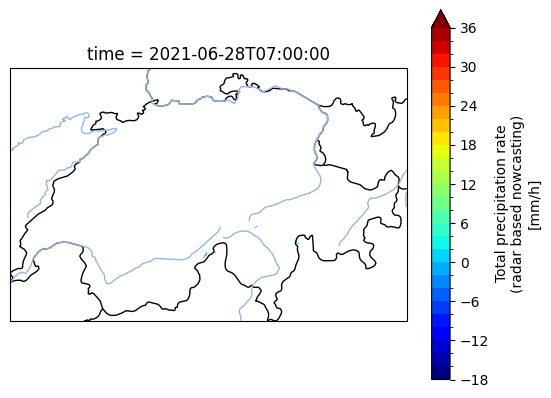

In [54]:
crs = ccrs.epsg(21781)

# plot the precipitation field on the original Swiss projection
ax1 = precip_field.where(precip_field > 0).plot(
    transform=crs,
    subplot_kws=dict(projection=crs),
    levels=levels,
    cmap=cmap
    ).axes
add_geo_features(ax1)

And for temperature

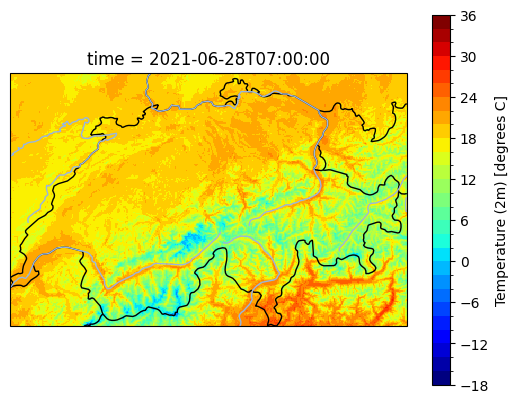

In [58]:
# plot the temperature field on the original Swiss projection
levels = np.arange(-18,38,2)
cmap = "jet"
ax1 = temp_field.plot(
    transform=crs,
    subplot_kws=dict(projection=crs),
    levels=levels,
    cmap=cmap
    ).axes
add_geo_features(ax1)

With Cartopy, we can easily switch to alternative geographical [projections](https://scitools.org.uk/cartopy/docs/latest/reference/crs.html#base-crs-s), here for example using Plate Carrée.

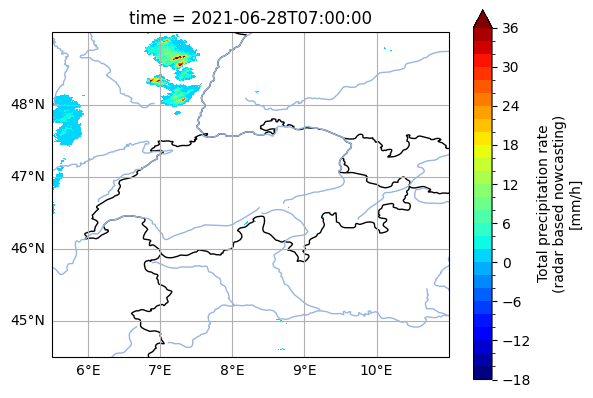

In [59]:
# plot the precipitation field on the Plate Carrée projection
ax = precip_field.where(precip_field > 0).plot(
    transform=crs,
    subplot_kws=dict(projection=ccrs.PlateCarree()),
    levels=levels,
    cmap=cmap
    ).axes
add_geo_features(ax)

# draw lat lon lines
grid_lines = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    dms=True
)
grid_lines.top_labels = grid_lines.right_labels = False
grid_lines.y_inline = grid_lines.x_inline = False
grid_lines.rotate_labels = False

# zoom on the map
ax.set_extent([5.5, 11, 44.5, 49])

## Read and plot INCA-CH digital elevation model

Download, read and plot the INCA-CH digital elevation model (1km horizontal resolution).

In [ ]:
!wget https://zenodo.org/records/7614565/files/DEM_1000m_CH03.nc

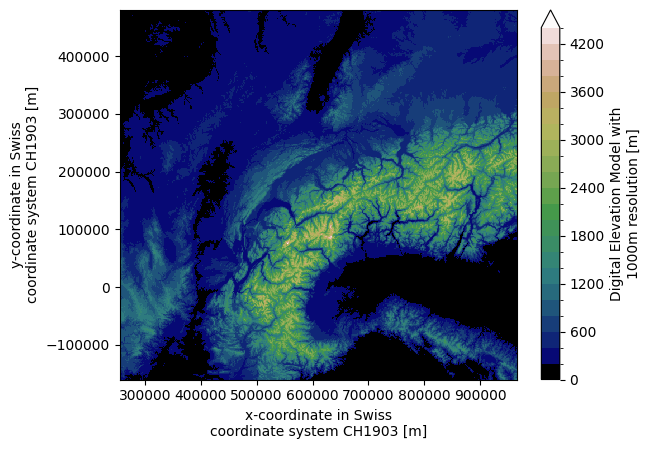

In [72]:
#Digital elevation model
ds5 = xr.open_dataset("DEM_1000m_CH03.nc")
DEM=ds5.DEM
levels = np.arange(DEM.min(),DEM.max(),200)
cmap = "gist_earth"
DEM.plot(levels=levels, cmap=cmap)

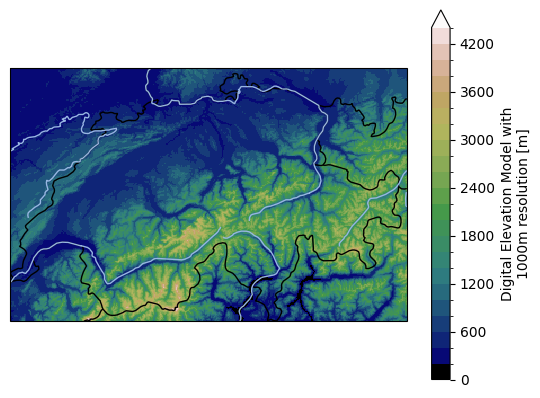

In [73]:
# plot DEM on the original Swiss projection

ax1 = DEM.plot(
    transform=crs,
    subplot_kws=dict(projection=crs),
    levels=levels,
    cmap=cmap
    ).axes
add_geo_features(ax1)